# Compact LLM policy across dimensions

This notebook compares the compact LLM-selected SMAC random-forest policy with 100-tree fixed controls and ten frozen fixed policies sampled from LLM decisions. The sampled policies are evaluated across objective dimensions 2, 5, 25, 50, and 100. The earlier 10-tree fixed runs are deliberately excluded. Lower objective values are better.

In [1]:
from pathlib import Path
import json, math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
HERE = Path.cwd()
if HERE.name != '40_02_different_dimensions':
    HERE = Path('experiments/synthaticBench/o1_deterministic/depth_policies/40_02_different_dimensions').resolve()
ROOT = HERE / 'results'
DIMENSIONS = (2, 5, 25, 50, 100)
SMAC_SEEDS = tuple(range(5))
DEPTHS = (5, 10, 15, 20, 30)
N_TRIALS = 1000
FIXED_POLICIES = [f'Fixed depth {d} (100 trees)' for d in DEPTHS]
SAMPLED_POLICIES = {
    'Sampled LLM d2 @100': 'fixed_llm_config_source_d2_cp100',
    'Sampled LLM d2 @500': 'fixed_llm_config_source_d2_cp500',
    'Sampled LLM d5 @100': 'fixed_llm_config_source_d5_cp100',
    'Sampled LLM d5 @500': 'fixed_llm_config_source_d5_cp500',
    'Sampled LLM d25 @100': 'fixed_llm_config_source_d25_cp100',
    'Sampled LLM d25 @500': 'fixed_llm_config_source_d25_cp500',
    'Sampled LLM d50 @100': 'fixed_llm_config_source_d50_cp100',
    'Sampled LLM d50 @500': 'fixed_llm_config_source_d50_cp500',
    'Sampled LLM d100 @100': 'fixed_llm_config_source_d100_cp100',
    'Sampled LLM d100 @500': 'fixed_llm_config_source_d100_cp500',
}
POLICIES = ['Compact LLM'] + FIXED_POLICIES + list(SAMPLED_POLICIES)
print(ROOT)

/rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/40_02_different_dimensions/results


## Load and coverage

Only completed trajectories are loaded. The coverage table makes missing or incomplete array tasks visible before interpreting the comparisons.

In [2]:
def path_for(dimension, policy, seed):
    if policy == 'Compact LLM':
        name = 'openai_compact_llm_rf_policy'
    elif policy in SAMPLED_POLICIES:
        name = SAMPLED_POLICIES[policy]
    else:
        depth = DEPTHS[FIXED_POLICIES.index(policy)]
        name = f'fixed_depth_{depth}_100_trees'
    return ROOT / f'dimension_{dimension}' / 'benchmark_seed_40' / name / str(seed) / 'trajectory.json'

runs = []
for dimension in DIMENSIONS:
    for policy in POLICIES:
        for seed in SMAC_SEEDS:
            path = path_for(dimension, policy, seed)
            if not path.exists():
                continue
            p = json.loads(path.read_text())
            runs.append(dict(dimension=dimension, policy=policy, smac_seed=seed,
                             iteration=np.asarray(p['iteration']), best=np.asarray(p['best_so_far']),
                             final=float(p['best_so_far'][-1]), payload=p, path=path))
coverage = pd.DataFrame([dict(dimension=r['dimension'], policy=r['policy'], smac_seed=r['smac_seed'],
                              trials=len(r['iteration']), final=r['final']) for r in runs])
expected = pd.MultiIndex.from_product([DIMENSIONS, POLICIES], names=['dimension', 'policy']).to_frame(index=False)
summary = (coverage.groupby(['dimension', 'policy']).agg(runs=('smac_seed','nunique'),
           minimum_trials=('trials','min'), maximum_trials=('trials','max')).reset_index()
           if len(coverage) else pd.DataFrame(columns=['dimension','policy','runs','minimum_trials','maximum_trials']))
display(expected.merge(summary, how='left').fillna(0))

,dimension,policy,runs,minimum_trials,maximum_trials
0,2,Compact LLM,5,1000,1000
1,2,Fixed depth 5 (100 trees),5,1000,1000
2,2,Fixed depth 10 (100 trees),5,1000,1000
3,2,Fixed depth 15 (100 trees),5,1000,1000
4,2,Fixed depth 20 (100 trees),5,1000,1000
...,...,...,...,...,...
75,100,Sampled LLM d25 @500,1,1000,1000
76,100,Sampled LLM d50 @100,1,1000,1000
77,100,Sampled LLM d50 @500,1,1000,1000
78,100,Sampled LLM d100 @100,1,1000,1000


## 1. Compact-policy trajectories

One plot per dimension shows the five SMAC seeds. Downward steps are improvements; dotted lines mark the three LLM decisions at trials 100, 250, and 500.

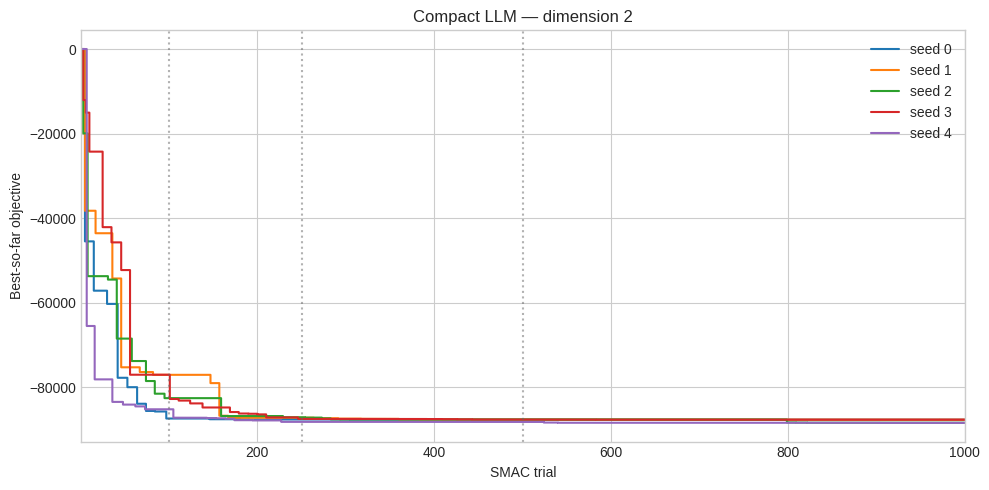

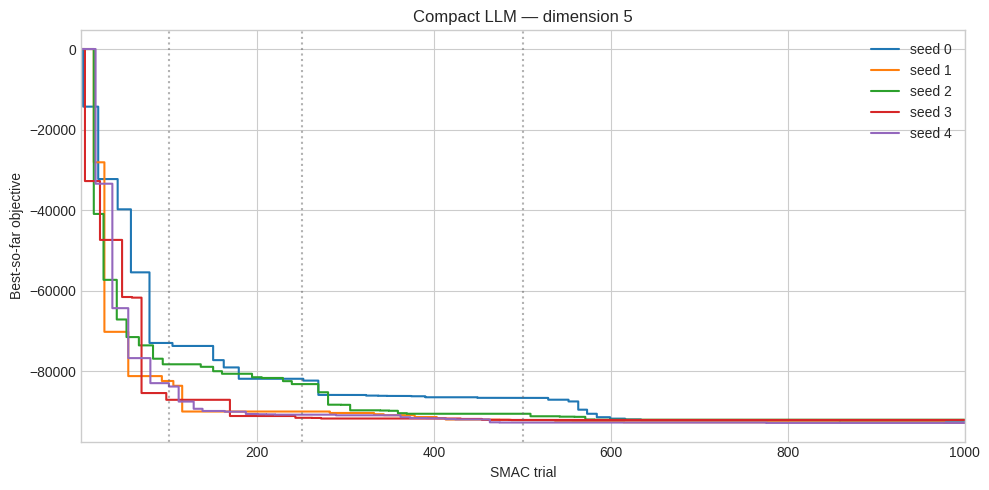

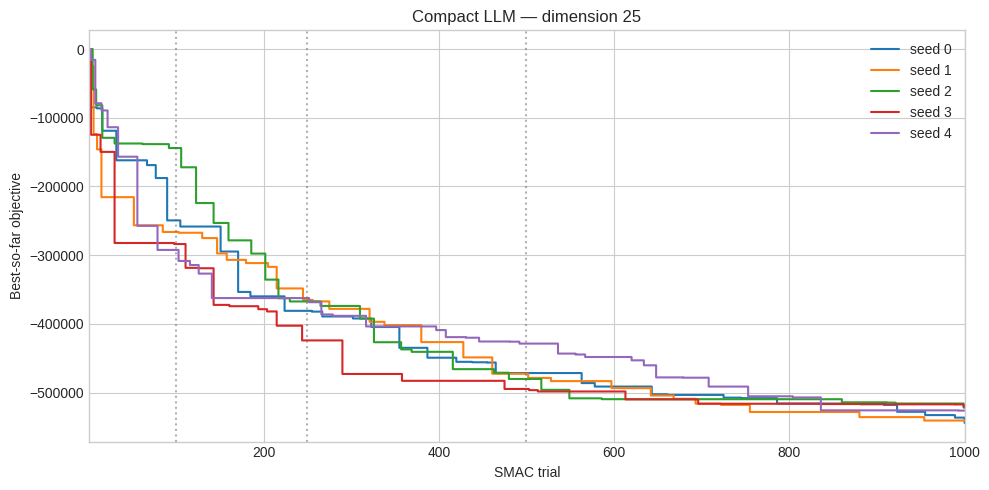

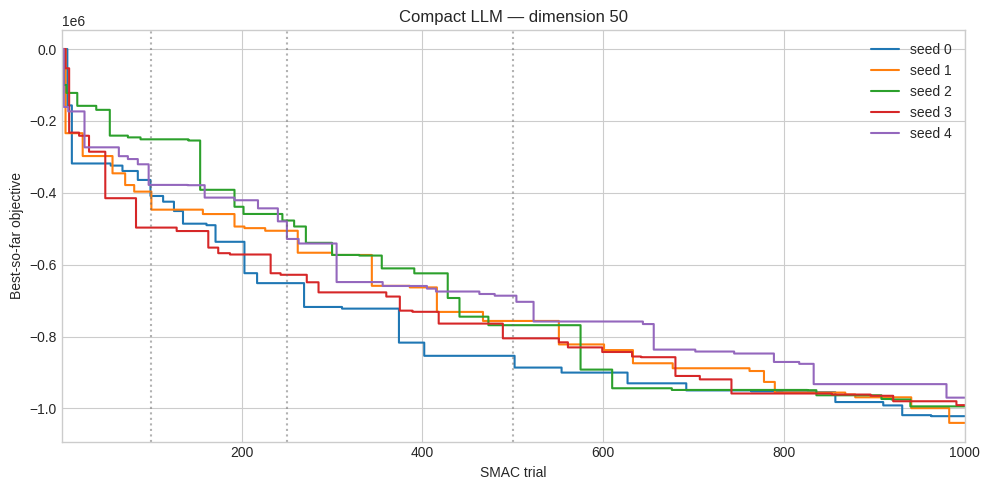

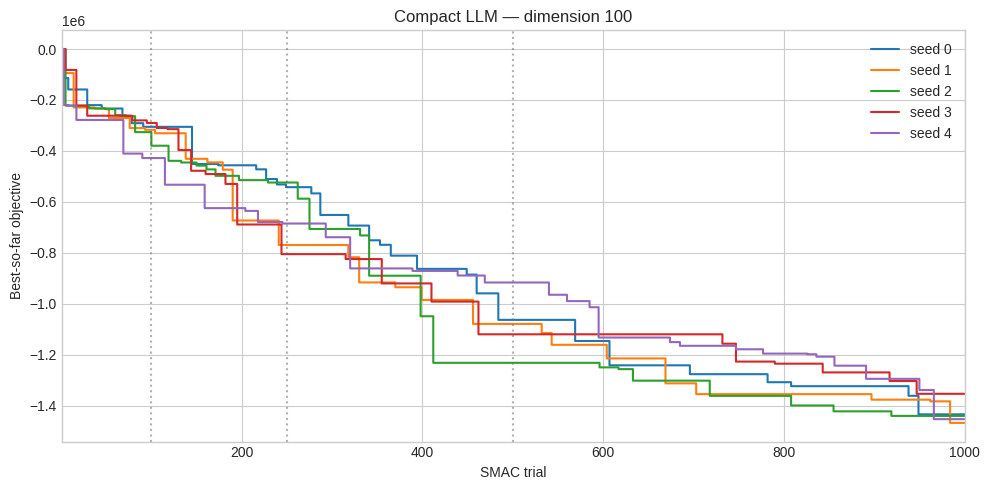

In [3]:
for dimension in DIMENSIONS:
    fig, ax = plt.subplots(figsize=(10, 5))
    for r in runs:
        if r['dimension'] == dimension and r['policy'] == 'Compact LLM':
            ax.step(r['iteration'], r['best'], where='post', label=f"seed {r['smac_seed']}")
    for checkpoint in (100, 250, 500): ax.axvline(checkpoint, color='0.4', ls=':', alpha=.5)
    ax.set(title=f'Compact LLM — dimension {dimension}', xlabel='SMAC trial', ylabel='Best-so-far objective', xlim=(1, N_TRIALS))
    ax.legend(); plt.tight_layout(); plt.show()

## 2. Compact policy versus 100-tree fixed depths

Only the new 100-tree fixed-depth runs are used here; the previous 10-tree controls are not loaded. Lines are mean best-so-far values across SMAC seeds; shading is a two-sided 95% Student-t confidence interval for the mean. It reflects seed uncertainty, not individual-run prediction uncertainty.

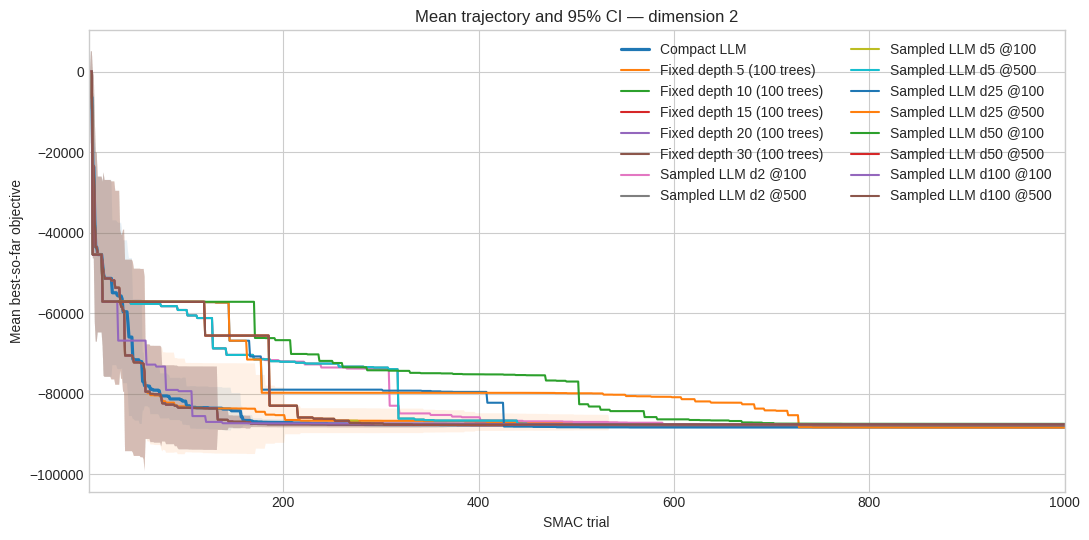

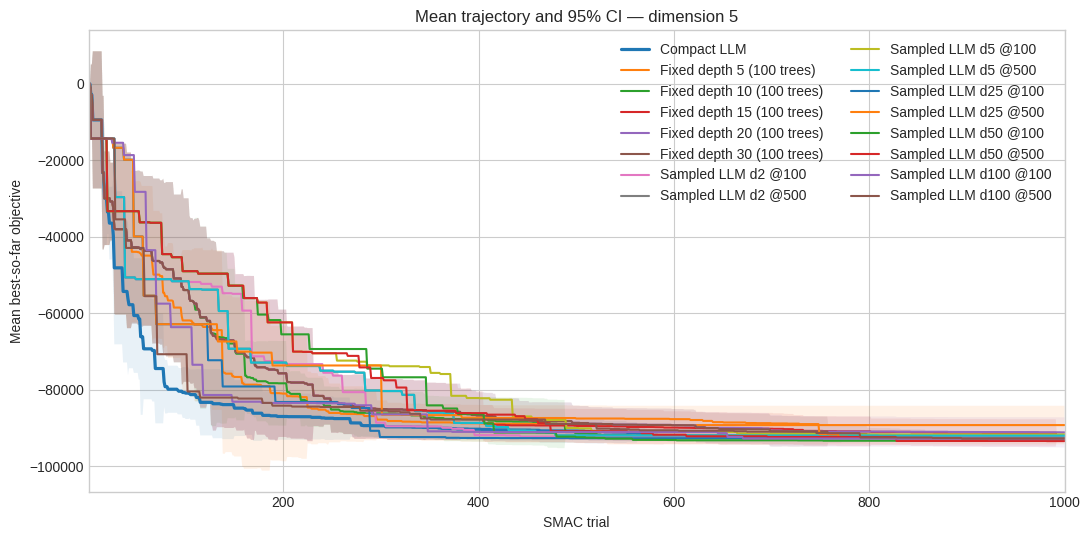

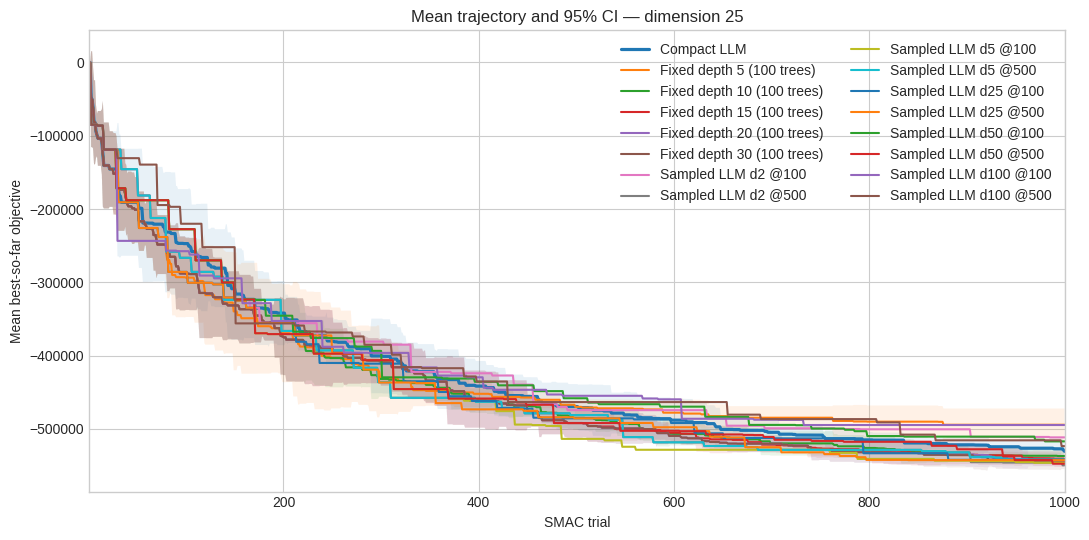

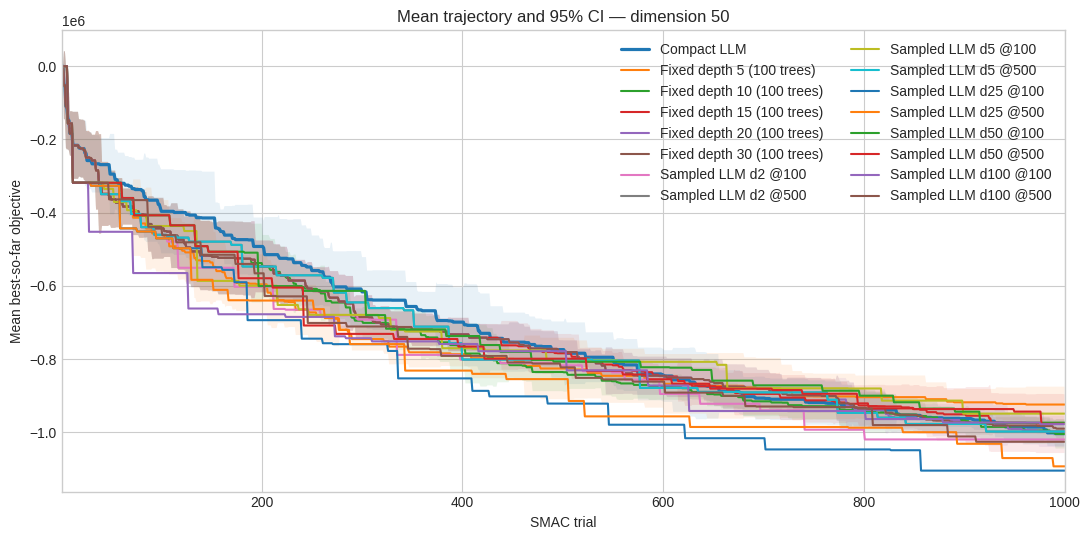

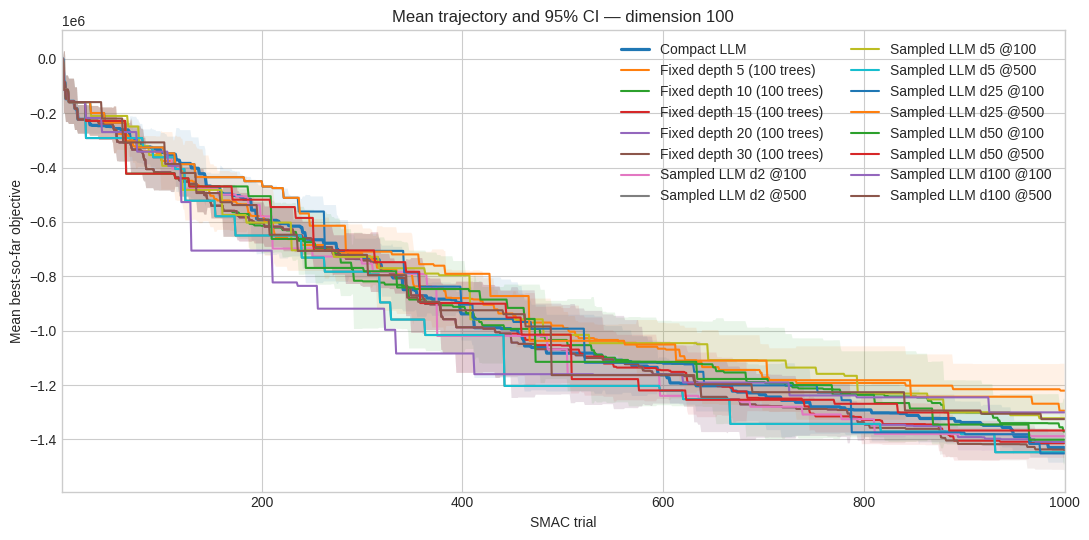

In [4]:
T95 = {2:12.706, 3:4.303, 4:3.182, 5:2.776}
def mean_ci(curves):
    a = np.vstack(curves); mean = a.mean(0)
    half = T95[len(a)] * a.std(0, ddof=1) / math.sqrt(len(a)) if len(a)>1 else np.zeros_like(mean)
    return mean, mean-half, mean+half

for dimension in DIMENSIONS:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for policy in POLICIES:
        selected = sorted([r for r in runs if r['dimension']==dimension and r['policy']==policy], key=lambda r:r['smac_seed'])
        if not selected or min(len(r['best']) for r in selected) < N_TRIALS: continue
        mean, lo, hi = mean_ci([r['best'][:N_TRIALS] for r in selected])
        x = np.arange(1, N_TRIALS+1); ax.plot(x, mean, label=policy, lw=2.3 if policy=='Compact LLM' else 1.5)
        ax.fill_between(x, lo, hi, alpha=.1)
    ax.set(title=f'Mean trajectory and 95% CI — dimension {dimension}', xlabel='SMAC trial', ylabel='Mean best-so-far objective', xlim=(1,N_TRIALS))
    ax.legend(ncol=2); plt.tight_layout(); plt.show()

## 3. Final-incumbent comparison

Every point is one SMAC seed's best value after trial 1,000. The boxplots expose both typical performance and seed variability; the table ranks policies by their mean final value within each dimension.

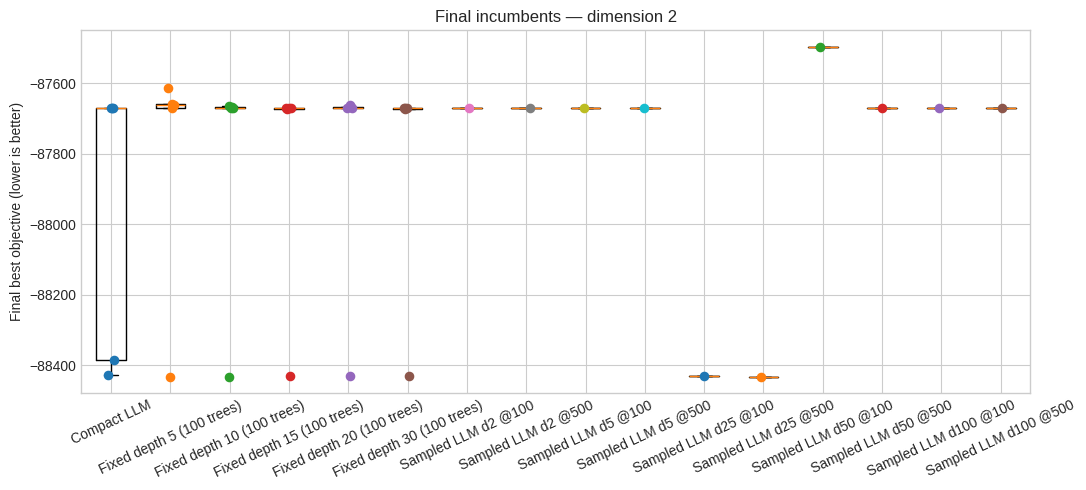

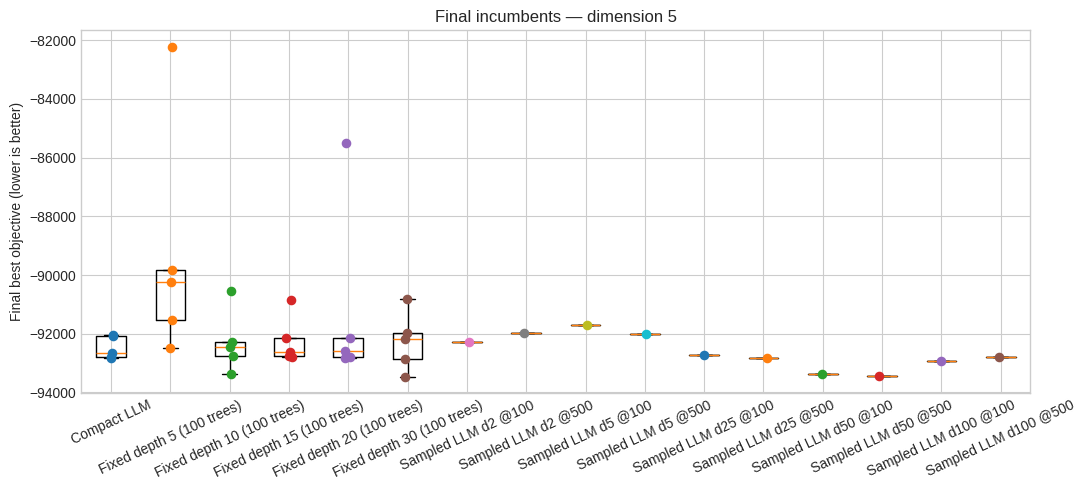

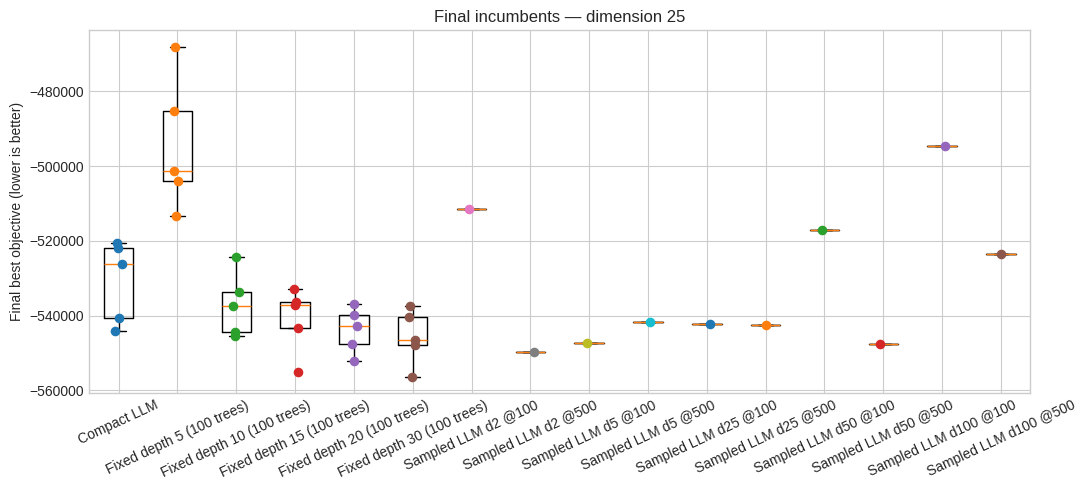

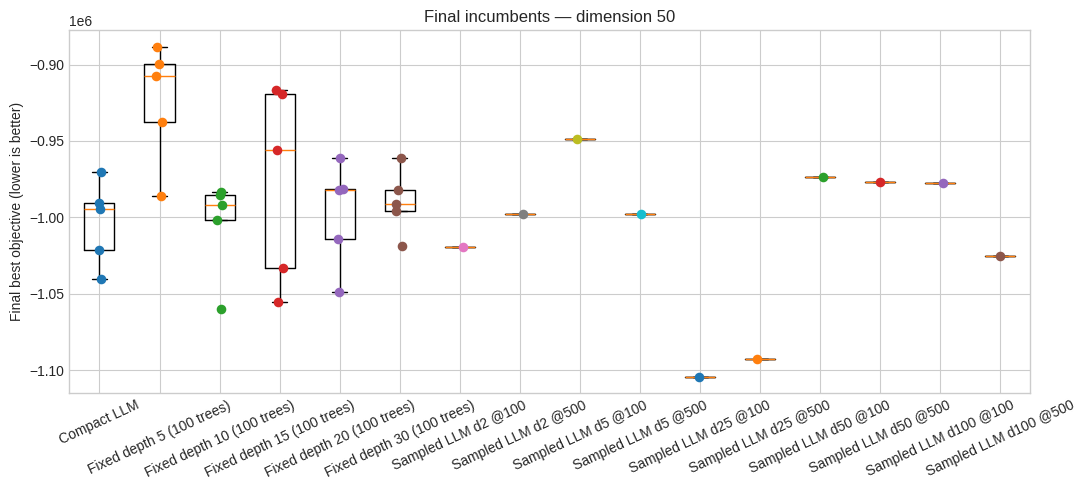

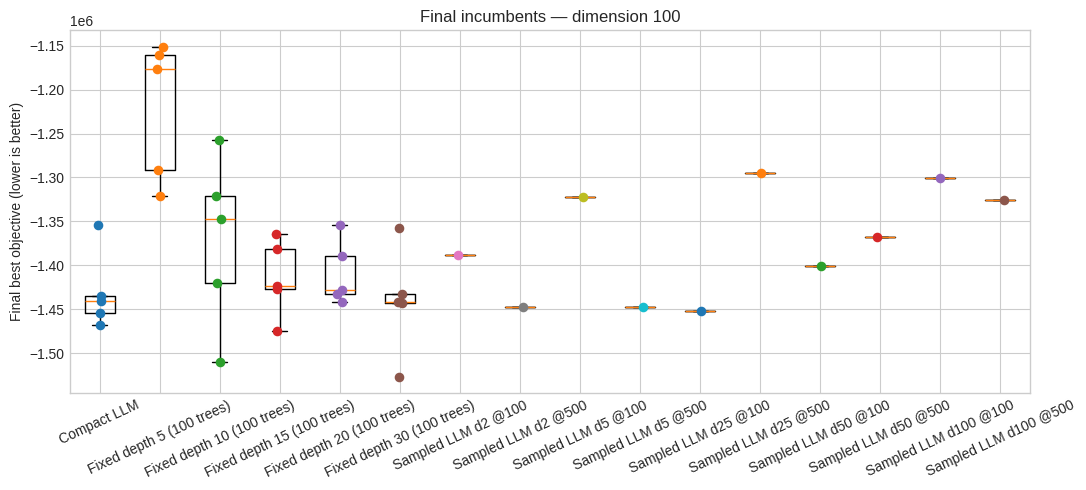

,dimension,policy,mean,std,median,min,max
11,2,Sampled LLM d25 @500,-8.843299e+04,NaN,-8.843299e+04,-8.843299e+04,-8.843299e+04
10,2,Sampled LLM d25 @100,-8.842997e+04,NaN,-8.842997e+04,-8.842997e+04,-8.842997e+04
0,2,Compact LLM,-8.796525e+04,403.776243,-8.767153e+04,-8.842784e+04,-8.767000e+04
4,2,Fixed depth 30 (100 trees),-8.782295e+04,339.880788,-8.767152e+04,-8.843095e+04,-8.766924e+04
2,2,Fixed depth 15 (100 trees),-8.782235e+04,340.090256,-8.767077e+04,-8.843072e+04,-8.766914e+04
...,...,...,...,...,...,...,...
71,100,Sampled LLM d100 @500,-1.325361e+06,NaN,-1.325361e+06,-1.325361e+06,-1.325361e+06
76,100,Sampled LLM d5 @100,-1.322192e+06,NaN,-1.322192e+06,-1.322192e+06,-1.322192e+06
70,100,Sampled LLM d100 @100,-1.300510e+06,NaN,-1.300510e+06,-1.300510e+06,-1.300510e+06
75,100,Sampled LLM d25 @500,-1.294368e+06,NaN,-1.294368e+06,-1.294368e+06,-1.294368e+06


In [5]:
complete = coverage[coverage.trials == N_TRIALS].copy()
for dimension in DIMENSIONS:
    part = complete[complete.dimension == dimension]
    values = [part.loc[part.policy==p, 'final'].values for p in POLICIES]
    if not all(len(v) for v in values): continue
    fig, ax = plt.subplots(figsize=(11,5)); ax.boxplot(values, tick_labels=POLICIES, showfliers=False)
    rng=np.random.default_rng(40+dimension)
    for i,v in enumerate(values,1): ax.scatter(i+rng.uniform(-.06,.06,len(v)),v,s=35,zorder=3)
    ax.set(title=f'Final incumbents — dimension {dimension}', ylabel='Final best objective (lower is better)')
    ax.tick_params(axis='x', rotation=25); plt.tight_layout(); plt.show()

ranking=(complete.groupby(['dimension','policy']).final.agg(['mean','std','median','min','max']).reset_index()
         .sort_values(['dimension','mean']))
display(ranking)

## 4. Rankings across policies

For each target dimension, policies are ranked by their average final incumbent objective across complete SMAC runs. Lower average objective is better, so rank 1 is best. The final table averages each policy's rank across dimensions; sampled policies currently have one evaluation seed unless additional seeds are submitted.

In [6]:
rank_by_dimension = (
    complete.groupby(['dimension', 'policy'])
    .agg(average_final=('final', 'mean'), runs=('final', 'size'))
    .reset_index()
)
rank_by_dimension['rank'] = (
    rank_by_dimension.groupby('dimension')['average_final']
    .rank(method='min', ascending=True)
    .astype('Int64')
)
rank_by_dimension = rank_by_dimension.sort_values(['dimension', 'rank', 'policy'])
display(rank_by_dimension)

average_rank = (
    rank_by_dimension.groupby('policy')
    .agg(average_rank=('rank', 'mean'), dimensions_ranked=('dimension', 'nunique'))
    .reset_index()
    .sort_values(['average_rank', 'policy'])
)
display(average_rank)

,dimension,policy,average_final,runs,rank
11,2,Sampled LLM d25 @500,-8.843299e+04,1,1
10,2,Sampled LLM d25 @100,-8.842997e+04,1,2
0,2,Compact LLM,-8.796525e+04,5,3
4,2,Fixed depth 30 (100 trees),-8.782295e+04,5,4
2,2,Fixed depth 15 (100 trees),-8.782235e+04,5,5
...,...,...,...,...,...
71,100,Sampled LLM d100 @500,-1.325361e+06,1,12
76,100,Sampled LLM d5 @100,-1.322192e+06,1,13
70,100,Sampled LLM d100 @100,-1.300510e+06,1,14
75,100,Sampled LLM d25 @500,-1.294368e+06,1,15


,policy,average_rank,dimensions_ranked
10,Sampled LLM d25 @100,3.4,5
11,Sampled LLM d25 @500,5.6,5
0,Compact LLM,6.4,5
4,Fixed depth 30 (100 trees),6.4,5
9,Sampled LLM d2 @500,6.4,5
1,Fixed depth 10 (100 trees),8.0,5
15,Sampled LLM d50 @500,8.0,5
13,Sampled LLM d5 @500,8.2,5
3,Fixed depth 20 (100 trees),8.6,5
2,Fixed depth 15 (100 trees),8.8,5


## 5. LLM choices by dimension and checkpoint

This table reports the exact RF settings returned at each decision. Frequencies reveal whether the model reacts differently to objective dimension or repeatedly collapses to the same choice. Token usage is included to make API cost auditable.

In [7]:
decisions=[]
for r in runs:
    if r['policy'] != 'Compact LLM': continue
    rows=r['payload'].get('llm_policy',{}).get('decisions',{})
    for checkpoint, row in rows.items():
        chosen=row.get('settings', {}); usage=row.get('usage') or {}
        decisions.append(dict(dimension=r['dimension'], smac_seed=r['smac_seed'], checkpoint=int(checkpoint),
            actual_completed_trials=row.get('actual_completed_trials_at_call'),
            **{k:chosen.get(k) for k in ['n_trees','max_depth','min_samples_split','min_samples_leaf','feature_ratio']},
            confidence=row.get('confidence'), input_tokens=usage.get('input_tokens'),
            output_tokens=usage.get('output_tokens'), reason=row.get('reason')))
decision_df=pd.DataFrame(decisions)
display(decision_df.sort_values(['dimension','smac_seed','checkpoint']) if len(decision_df) else decision_df)
if len(decision_df):
    display(decision_df.groupby(['dimension','checkpoint','n_trees','max_depth','min_samples_split','min_samples_leaf','feature_ratio']).size().rename('count').reset_index().sort_values(['dimension','checkpoint','count'],ascending=[True,True,False]))
    display(decision_df.groupby(['dimension','checkpoint'])[['input_tokens','output_tokens']].mean().round(1).rename(columns=lambda x:'mean_'+x))

,dimension,smac_seed,checkpoint,actual_completed_trials,n_trees,max_depth,min_samples_split,min_samples_leaf,feature_ratio,confidence,input_tokens,output_tokens,reason
0,2,0,100,106,100,10,2,1,1.000000,0.78,4286,275,The 2D continuous space benefits from using bo...
1,2,0,250,250,100,15,2,1,1.000000,0.74,4430,222,The two-dimensional continuous space benefits ...
2,2,0,500,500,100,30,2,1,1.000000,0.76,4464,265,"Both features are informative in the 2D space,..."
3,2,1,100,100,50,12,3,2,1.000000,0.72,4406,347,Two-dimensional space favors using both featur...
4,2,1,250,250,100,18,2,1,1.000000,0.78,4441,291,Recent trees nearly saturate the depth-12 cap ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,100,3,250,253,100,15,3,2,0.833333,0.72,6592,313,Recent trees use about 81% of the depth-12 lim...
71,100,3,500,500,100,18,4,2,0.833333,0.68,6640,385,Recent trees use about 80% of depth 15 and rea...
72,100,4,100,100,60,20,3,3,0.833333,0.72,6499,455,Increase ensemble size substantially to stabil...
73,100,4,250,254,80,12,8,4,0.833333,0.66,6584,424,"Later windows show substantial, intermittently..."


,dimension,checkpoint,n_trees,max_depth,min_samples_split,min_samples_leaf,feature_ratio,count
3,2,100,100,12,2,1,1.000000,2
0,2,100,50,12,2,1,1.000000,1
1,2,100,50,12,3,2,1.000000,1
2,2,100,100,10,2,1,1.000000,1
4,2,250,100,15,2,1,1.000000,1
...,...,...,...,...,...,...,...,...
61,100,500,100,16,6,3,0.833333,1
62,100,500,100,18,4,2,0.833333,1
63,100,500,100,20,2,1,0.500000,1
64,100,500,100,20,2,1,0.700000,1


mean_input_tokens  mean_output_tokens
dimension checkpoint                                       
2         100                    4373.0               319.2
          250                    4442.8               310.2
          500                    4478.0               326.4
5         100                    4434.2               393.6
          250                    4508.2               288.6
          500                    4560.8               321.8
25        100                    4922.6               384.2
          250                    4972.6               445.0
          500                    5022.0               289.0
50        100                    5452.4               431.6
          250                    5506.4               305.0
          500                    5557.0               359.6
100       100                    6495.4               450.0
          250                    6562.0               327.8
          500                    6616.8               361.8

### 5a. Complete 100D decisions and reasons

This dedicated table contains all three decisions for every 100D SMAC seed. `checkpoint` is the requested threshold; `actual_completed_trials` is when the callback was able to make the API call. The five RF columns are the settings applied to the next model-training phase. The reason is shown without truncation.

In [8]:
decision_columns = [
    'smac_seed', 'checkpoint', 'actual_completed_trials',
    'n_trees', 'max_depth', 'min_samples_split', 'min_samples_leaf',
    'feature_ratio', 'confidence', 'input_tokens', 'output_tokens', 'reason',
]
decisions_100d = (
    decision_df.loc[decision_df['dimension'].eq(100), decision_columns]
    .sort_values(['smac_seed', 'checkpoint'])
    .reset_index(drop=True)
)
assert len(decisions_100d) == len(SMAC_SEEDS) * 3, (
    f'Expected 15 decisions for 100D, found {len(decisions_100d)}.'
)
with pd.option_context('display.max_colwidth', None, 'display.max_rows', None):
    display(decisions_100d.style.set_properties(
        subset=['reason'], **{'text-align': 'left', 'white-space': 'pre-wrap'}
    ))

,smac_seed,checkpoint,actual_completed_trials,n_trees,max_depth,min_samples_split,min_samples_leaf,feature_ratio,confidence,input_tokens,output_tokens,reason
0,0,100,100,50,12,2,1,0.500000,0.740000,6496,518,"Increase ensemble stability and tree diversity while relaxing leaf-size regularization to improve fit; the current depth limit is unused, predictions remain biased, and variance calibration is inconsistent."
1,0,250,258,100,16,2,1,0.500000,0.670000,6546,362,"Recent trees are consistently depth-limited (96% utilization at depth 12), while final-window progress and proxy accuracy improved under the current fine-leaf model. Increase depth moderately and use more trees for stabler acquisition uncertainty, while retaining the effective 0.5 feature subsampling and minimally regularized splits."
2,0,500,500,100,20,2,1,0.500000,0.740000,6599,396,"Recent trees consistently use about 88% of the depth-16 cap, while objective improvements remain substantial and proxy relative error is low. Raising only the depth limit should reduce active truncation and improve local modeling; retain 100 trees, leaf size 1, split 2, and 0.5 feature ratio because the 100-dimensional sparse-data regime still benefits from ensemble diversity."
3,1,100,102,50,12,4,2,0.700000,0.720000,6488,453,"Increase ensemble size to stabilize highly variable marginalized means and variance estimates; use moderately smaller feature subsampling for tree diversity in 100 dimensions. Slightly smaller leaves allow useful local resolution, while depth 12 remains above observed attainable depths and avoids unnecessary deep-tree overfitting."
4,1,250,250,100,15,2,1,0.700000,0.740000,6539,275,Recent trees are approaching the depth cap (mean utilization 0.86) while marginalized predictions remain materially biased; a modest depth increase and less restrictive splitting should reduce underfitting. Retain the effective feature ratio and increase trees to stabilize acquisition uncertainty in the 100-dimensional space.
5,1,500,500,100,20,2,1,0.700000,0.760000,6594,247,"Recent trees nearly saturate depth 15 (0.936 utilization) while proxy errors are relatively low and improvement resumed, so allow moderately deeper partitions; retain the otherwise effective high-capacity ensemble and feature subsampling."
6,2,100,109,50,12,2,1,0.800000,0.700000,6500,315,"With only 44 unique configurations in a 100D continuous space, the current leaf size of 3 is the main constraint on tree resolution; observed depths remain far below the limit. Smaller leaves and split threshold improve local discrimination, while 50 trees stabilizes mean/variance estimates. A depth limit of 12 remains nonbinding enough for the available data but guards against overly irregular trees; retaining a high feature ratio is appropriate for the high-dimensional likely dense objective."
7,2,250,250,100,16,4,2,0.800000,0.720000,6549,265,"Recent trees nearly saturate depth 12 while late-window proxy errors remain large and variance-error correlation has become nonpositive. More trees should stabilize acquisition estimates; modestly deeper trees retain needed resolution, while leaf/split regularization reduces brittle single-observation partitions in this 100D, sparsely replicated regime."
8,2,500,500,100,20,4,2,0.800000,0.720000,6604,464,"Keep the stable 100-tree, high-feature, lightly regularized forest that supported large gains through trial 450. Recent actual depths (~12.6 versus limit 16) indicate the depth cap is becoming constraining; a moderate increase to 20 adds local discrimination without materially changing regularization. Do not reduce leaf size or split threshold because variance-error correlation remains weak and the last window plateaued despite optimistic predictions."
9,3,100,104,80,12,3,2,0.833333,0.740000,6494,509,"Increase ensemble stability and modestly increase local resolution; the current depth limit is not binding, while leaf-size regularization appears to limit useful partitioning in the sparse 100D